## The goal of the code:
This is a step-by-step code to be fmiliar with the simulation of a forex strategy testing.

The m-period and n-period MA crossover (m < n) is a common strategy. When the short MA crosses above the long MA, it's a buy signal, and vice versa for a sell

1. Calculate the moving averages.

2. Generate buy/sell signals.

3. Simulate trades based on these signals, using the ATR indicator to choose SL and TP.

4. Compute performance metrics.

5. Visualize the results.

Note: We use ATR, a volatility measure, for stop-loss and take-profit, replacing fixed percentages for better adaptability.

### Importing main libraries

In [1]:

import yfinance as yf
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

### Fteching, cleaning and arranging of forex data 

In [4]:
# Parameters
pair = "EURUSD=X"
start_date = "2024-01-01"
end_date = "2024-02-28"
interval = "1h"

In [5]:
# Fetch data
# fxdata = yf.download(pair, start=start_date, end=end_date, interval=interval)
# fxdata = fxdata[['Open', 'High', 'Low', 'Close']]  # OHLC only
fxdata = yf.Ticker(pair)

In [6]:
fxdata = fxdata.history(start=start_date, end=end_date, interval=interval)
fxdata

,Open,High,Low,Close,Volume,Dividends,Stock Splits
Datetime,,,,,,,
2024-01-01 18:00:00+00:00,1.105583,1.105583,1.105583,1.105583,0,0.0,0.0
2024-01-01 19:00:00+00:00,1.105583,1.105583,1.105339,1.105339,0,0.0,0.0
2024-01-01 20:00:00+00:00,1.105339,1.105339,1.103875,1.104240,0,0.0,0.0
2024-01-01 21:00:00+00:00,1.104240,1.105217,1.104240,1.105217,0,0.0,0.0
2024-01-01 22:00:00+00:00,1.104850,1.105094,1.104606,1.104728,0,0.0,0.0
...,...,...,...,...,...,...,...
2024-02-27 19:00:00+00:00,1.085305,1.085305,1.084363,1.084716,0,0.0,0.0
2024-02-27 20:00:00+00:00,1.084716,1.085069,1.084481,1.084716,0,0.0,0.0
2024-02-27 21:00:00+00:00,1.084716,1.084952,1.084716,1.084834,0,0.0,0.0


In [7]:
cols = ['Volume', 'Dividends','Stock Splits']   
(fxdata[cols] == 0).all()
fxdata.drop(columns= cols, inplace = True)
fxdata

,Open,High,Low,Close
Datetime,,,,
2024-01-01 18:00:00+00:00,1.105583,1.105583,1.105583,1.105583
2024-01-01 19:00:00+00:00,1.105583,1.105583,1.105339,1.105339
2024-01-01 20:00:00+00:00,1.105339,1.105339,1.103875,1.104240
2024-01-01 21:00:00+00:00,1.104240,1.105217,1.104240,1.105217
2024-01-01 22:00:00+00:00,1.104850,1.105094,1.104606,1.104728
...,...,...,...,...
2024-02-27 19:00:00+00:00,1.085305,1.085305,1.084363,1.084716
2024-02-27 20:00:00+00:00,1.084716,1.085069,1.084481,1.084716
2024-02-27 21:00:00+00:00,1.084716,1.084952,1.084716,1.084834


In [8]:
fxdata.info()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 982 entries, 2024-01-01 18:00:00+00:00 to 2024-02-27 23:00:00+00:00
Data columns (total 4 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   Open    982 non-null    float64
 1   High    982 non-null    float64
 2   Low     982 non-null    float64
 3   Close   982 non-null    float64
dtypes: float64(4)
memory usage: 38.4 KB


In [9]:
fxdata = pd.DataFrame(fxdata)
fxdata.index = pd.to_datetime(fxdata.index)

In [10]:
data=fxdata.copy()

### Calculation of moving averages and ATR

In [11]:
m, n = 14, 70  # Short and long MA periods
atr_period = 14

In [12]:
# Calculate MAs and ATR
data['MA_Short'] = data['Close'].rolling(window=m).mean()
data['MA_Long'] = data['Close'].rolling(window=n).mean()
# This code calculates the True Range (TR) as part of computing the Average True Range (ATR) indicator.
data['TR'] = np.maximum.reduce([
                                data['High'] - data['Low'],
                                abs(data['High'] - data['Close'].shift()),
                                abs(data['Low'] - data['Close'].shift())
                               ])

In [13]:
# Use EMA for ATR, following Wilder's method
data['ATR'] = data['TR'].ewm(span=atr_period, adjust=False).mean()

In [14]:
# Drop NaN rows (after all calculations)
data = data.dropna()

In [15]:
# Generate signals
data['Position'] = 0
data.loc[data['MA_Short'] > data['MA_Long'], 'Position'] = 1  # Long
data.loc[data['MA_Short'] < data['MA_Long'], 'Position'] = -1  # Short

In [16]:
from itables import show
show(data)

### The main loop: trading simulation logic

In [17]:
# Using ATR
# Simulate trades with SL/TP

initial_balance = 10000
sl_multiplier = 2   # 3  # 2x ATR for stop-loss
tp_multiplier = 4     # 6  # 4x ATR for take-profit
capital = initial_balance
position = 0
entry_price = None
trade_log = []

for i in range(len(data) - 1):         # Main loop
    current = data.iloc[i]
    next_data = data.iloc[i + 1]
    atr = current['ATR'].item()
    if position == 0:  # No position, look for entry
        if current['Position'].item() == 1:  # Buy signal
            entry_price = current['Close'].item()
            sl_price = entry_price - sl_multiplier * atr
            tp_price = entry_price + tp_multiplier * atr
            position = capital / entry_price
            #capital = 0
            trade_log.append(("BUY", current.name, entry_price, sl_price, tp_price))
        elif current['Position'].item() == -1:  # Short signal
            entry_price = current['Close'].item()
            sl_price = entry_price + sl_multiplier * atr  # For short, SL is above
            tp_price = entry_price - tp_multiplier * atr  # For short, TP is below
            position = -capital / entry_price  # Negative for short
            #capital = 0
            trade_log.append(("SHORT", current.name, entry_price, sl_price, tp_price))
    else:  # Have position, check SL/TP or signal change
        current_price = current['Close'].item()
        if position > 0:  # Long position
            #if next_data['Low'].item() <= sl_price or current_price >= tp_price:
            if current_price <= sl_price or current_price >= tp_price:
                if current_price <= sl_price:
                    exit_price = sl_price
                    reason = "SL"
                else:
                    exit_price = tp_price
                    reason = "TP"
                capital = position * exit_price
                position = 0
                trade_log.append((reason, current.name, exit_price,capital))
            # elif current['Position'].item() == -1:  # Signal changed to short, close long
            #     capital = position * current_price
            #     position = 0
            #     trade_log.append(("CLOSE_LONG", current.name, current_price))
        else:  # Short position
            if current_price >= sl_price or current_price <= tp_price:
                if current_price >= sl_price:
                    exit_price = sl_price
                    reason = "SL"
                    capital = capital * exit_price/entry_price  # Negative position, so positive capital
                else:
                    exit_price = tp_price
                    reason = "TP"
                    capital = capital * entry_price /exit_price
                # capital = -position * exit_price  # Negative position, so positive capital
                position = 0
                trade_log.append((reason, current.name, exit_price,capital))
            # elif current['Position'].item() == 1:  # Signal changed to long, close short
            #     capital = -position * current_price
            #     position = 0
            #     trade_log.append(("CLOSE_SHORT", current.name, current_price))

# Close any open position at last price
if position != 0:
    last_price = data.iloc[-1]['Close']
    if position > 0:
        capital = position * last_price
    else:
        capital = -position * last_price
    trade_log.append(("CLOSE", data.index[-1], last_price,capital))

final_balance = capital
returns = (final_balance - initial_balance) / initial_balance * 100

In [18]:
trade_log

[('SHORT',
  Timestamp('2024-01-04 15:00:00+0000', tz='Europe/London'),
  1.0957703590393066,
  1.0984755446460597,
  1.0903599878258003),
 ('SL',
  Timestamp('2024-01-11 06:00:00+0000', tz='Europe/London'),
  1.0984755446460597,
  10024.687523115013),
 ('BUY',
  Timestamp('2024-01-11 07:00:00+0000', tz='Europe/London'),
  1.0982975959777832,
  1.096657244147408,
  1.1015782996385335),
 ('SL',
  Timestamp('2024-01-11 09:00:00+0000', tz='Europe/London'),
  1.096657244147408,
  10009.715247305887),
 ('BUY',
  Timestamp('2024-01-11 10:00:00+0000', tz='Europe/London'),
  1.0969723463058472,
  1.0951495013460881,
  1.1006180362253655),
 ('SL',
  Timestamp('2024-01-11 13:00:00+0000', tz='Europe/London'),
  1.0951495013460881,
  9993.082048621689),
 ('BUY',
  Timestamp('2024-01-11 14:00:00+0000', tz='Europe/London'),
  1.0955302715301514,
  1.0917441895715971,
  1.10310243544726),
 ('SL',
  Timestamp('2024-01-16 08:00:00+0000', tz='Europe/London'),
  1.0917441895715971,
  9958.546601598582),


In [19]:
type(trade_log)

list

In [20]:
returns

np.float64(2.526687602589409)

In [21]:
 final_balance

np.float64(10252.66876025894)

In [22]:
returns

np.float64(2.526687602589409)

### Plot close price, moving averages and trading signals

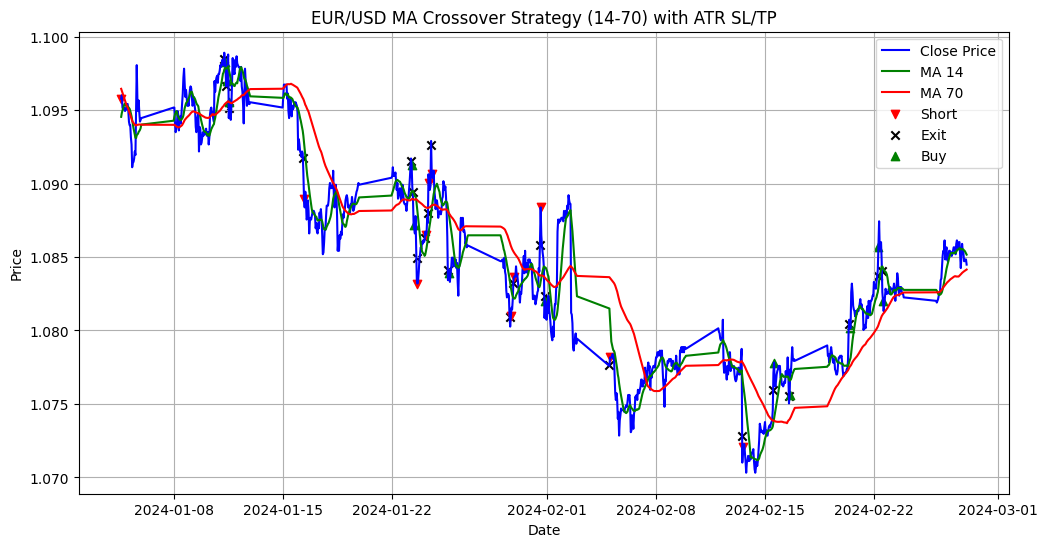

In [23]:
# Visualization
plt.figure(figsize=(12, 6))
plt.plot(data.index, data['Close'], label="Close Price", color="blue")
plt.plot(data.index, data['MA_Short'], label=f"MA {m}", color="green")
plt.plot(data.index, data['MA_Long'], label=f"MA {n}", color="red")

# Track which labels have been used
plotted_labels = {"Buy": False, "Short": False, "Exit": False}

# Plot signals
for log in trade_log:
    if log[0] == "BUY":
        plt.scatter(log[1], log[2], marker="^", color="green",
                    label="Buy" if not plotted_labels["Buy"] else "")
        plotted_labels["Buy"] = True
    elif log[0] == "SHORT":
        plt.scatter(log[1], log[2], marker="v", color="red",
                    label="Short" if not plotted_labels["Short"] else "")
        plotted_labels["Short"] = True
    elif log[0] in ["SL", "TP"]:
        plt.scatter(log[1], log[2], marker="x", color="black",
                    label="Exit" if not plotted_labels["Exit"] else "")
        plotted_labels["Exit"] = True

plt.legend()
plt.title(f"EUR/USD MA Crossover Strategy ({m}-{n}) with ATR SL/TP")
plt.xlabel("Date")
plt.ylabel("Price")
plt.grid()
plt.show()

### Build Equity Curve 

In [24]:
# Build equity curve from trade_log
equity_dates = []
equity_values = []

for log in trade_log:
    if log[0] in ["TP", "SL", "CLOSE"]:  # Only add points when capital updates
        equity_dates.append(log[1])     # log[1] is timestamp
        equity_values.append(log[3])    # log[3] is capital after trade

equity_curve = pd.Series(equity_values, index=pd.to_datetime(equity_dates))
returns_series = equity_curve.pct_change().dropna()

### Plot the Equity Curve

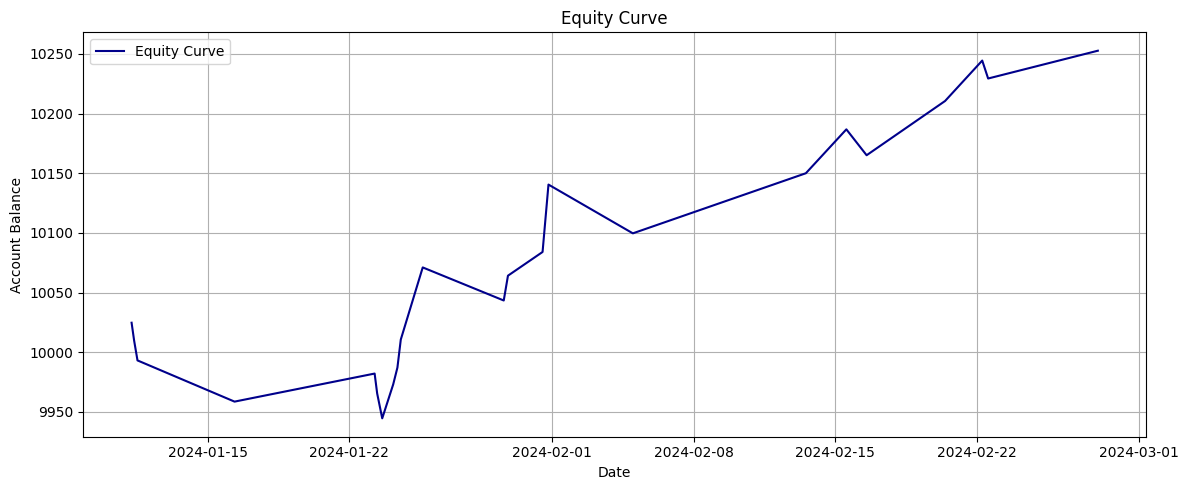

In [25]:
plt.figure(figsize=(12, 5))
plt.plot(equity_curve, label="Equity Curve", color="darkblue")
plt.title("Equity Curve")
plt.xlabel("Date")
plt.ylabel("Account Balance")
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()

### Calculate Metrics

In [26]:
# Calculate metrics

# Time-based annualization
total_hours = (data.index[-1] - data.index[0]).total_seconds() / 3600
bars_per_day = len(data) / (total_hours / 24) if total_hours > 0 else 1
annualization_factor = 252 * bars_per_day

if len(returns_series) > 0:
    total_return = (equity_curve.iloc[-1] / equity_curve.iloc[0] - 1) * 100
    annualized_return = (1 + returns_series.mean()) ** annualization_factor - 1
    annualized_vol = returns_series.std() * np.sqrt(annualization_factor)
    sharpe = annualized_return / annualized_vol if annualized_vol != 0 else np.nan

    # Max drawdown
    cumulative = equity_curve.cummax()
    drawdown = (equity_curve - cumulative) / cumulative
    max_dd = drawdown.min() * 100

    win_rate = (returns_series > 0).mean() * 100
    total_profit = returns_series[returns_series > 0].sum()
    total_loss = -returns_series[returns_series < 0].sum()
    profit_factor = total_profit / total_loss if total_loss > 0 else np.nan
else:
    total_return = annualized_return = annualized_vol = sharpe = max_dd = 0
    win_rate = profit_factor = 0


### Print Summary

In [27]:
print("\n=== Strategy Performance Summary ===")
print(f"Total Return         : {total_return:.2f}%")
print(f"Annualized Return    : {annualized_return:.2f}%")
print(f"Annualized Volatility: {annualized_vol:.2f}")
print(f"Sharpe Ratio         : {sharpe:.2f}")
print(f"Max Drawdown         : {max_dd:.2f}%")
print(f"Win Rate             : {win_rate:.2f}%")
print(f"Profit Factor        : {profit_factor:.2f}")


=== Strategy Performance Summary ===
Total Return         : 2.27%
Annualized Return    : 76.31%
Annualized Volatility: 0.20
Sharpe Ratio         : 377.20
Max Drawdown         : -0.80%
Win Rate             : 59.09%
Profit Factor        : 2.09
